In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load datasets from local folder
movies = pd.read_csv('data/ml-20m/movies.csv')
ratings = pd.read_csv('data/ml-20m/ratings.csv')
tags = pd.read_csv('data/ml-20m/tags.csv')

print("Data loaded successfully!")

Data loaded successfully!


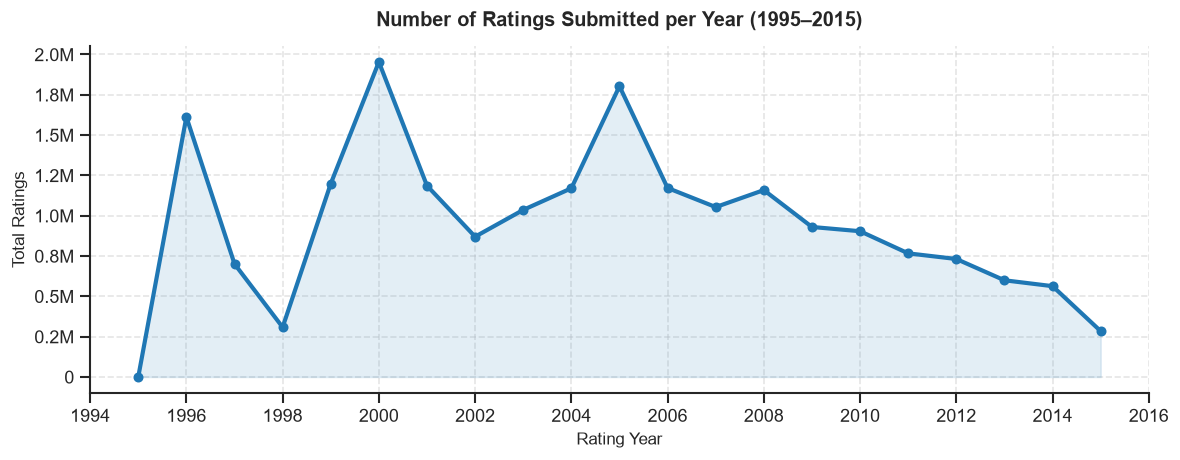

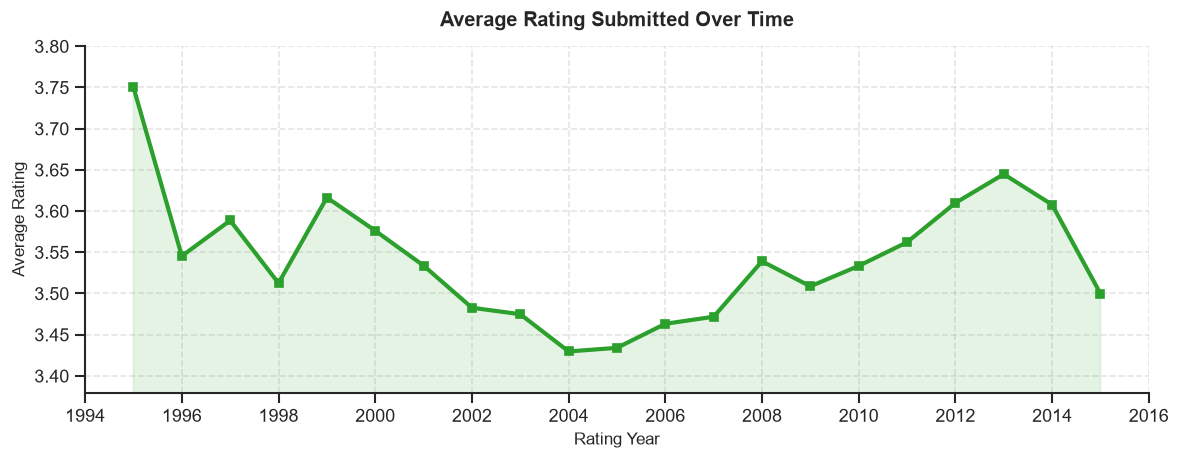

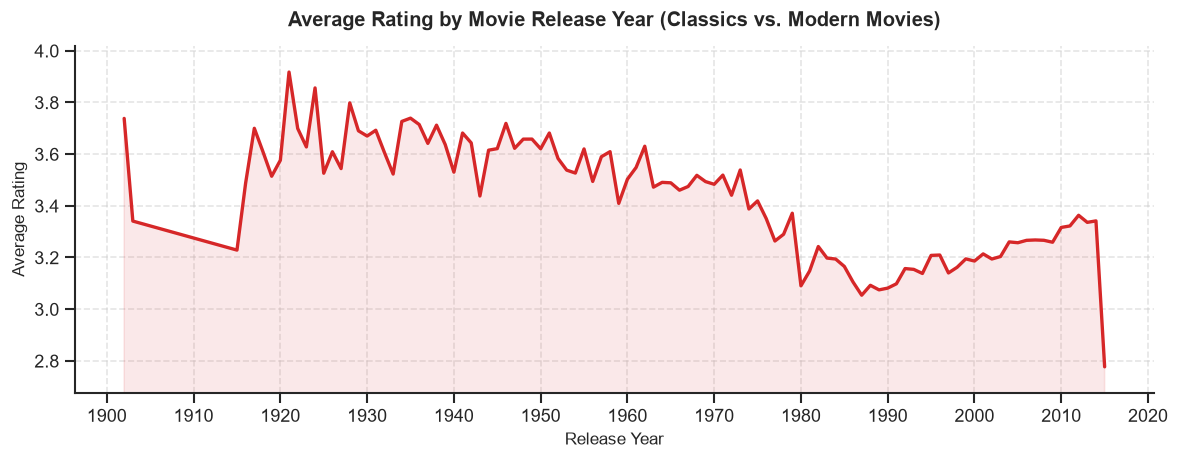

In [11]:
import matplotlib.ticker as ticker

# Globales Styling (Ticks-Design & hohe Auflösung)
sns.set_theme(style="ticks")
plt.rcParams['figure.dpi'] = 120

# 1. Daten vorbereiten
ratings['rating_year'] = pd.to_datetime(ratings['timestamp'], unit='s').dt.year
movies['release_year'] = movies['title'].str.extract(r'\((\d{4})\)$')[0].astype(float)


# --- Plot 1: Total Ratings Submitted per Year ---
fig, ax = plt.subplots(figsize=(10, 4))
ratings_per_year = ratings.groupby('rating_year').size()

ax.plot(ratings_per_year.index, ratings_per_year.values, marker='o', linewidth=2.5, color='#1f77b4', markersize=5)
ax.fill_between(ratings_per_year.index, ratings_per_year.values, color='#1f77b4', alpha=0.12)

ax.set_title('Number of Ratings Submitted per Year (1995–2015)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Rating Year', fontsize=10)
ax.set_ylabel('Total Ratings', fontsize=10)

ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x*1e-6:.1f}M' if x > 0 else '0'))

ax.grid(True, linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()


# --- Plot 2: Average Rating Submitted Over Time ---
fig, ax = plt.subplots(figsize=(10, 4))
avg_rating_per_year = ratings.groupby('rating_year')['rating'].mean()

ax.plot(avg_rating_per_year.index, avg_rating_per_year.values, marker='s', linewidth=2.5, color='#2ca02c', markersize=5)
ax.fill_between(avg_rating_per_year.index, avg_rating_per_year.values, color='#2ca02c', alpha=0.12)

ax.set_title('Average Rating Submitted Over Time', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Rating Year', fontsize=10)
ax.set_ylabel('Average Rating', fontsize=10)

# Dynamische Grenzen: Zentriert die Kurve perfekt im Bild
y_min2, y_max2 = avg_rating_per_year.min(), avg_rating_per_year.max()
ax.set_ylim(y_min2 - 0.05, y_max2 + 0.05)

ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.grid(True, linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()


# --- Plot 3: Ratings by Movie Release Year (Classics vs Modern) ---
movie_avg_ratings = ratings.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index()
movies_with_ratings = pd.merge(movies, movie_avg_ratings, on='movieId')

filtered_movies = movies_with_ratings[(movies_with_ratings['release_year'] >= 1900) & (movies_with_ratings['count'] >= 50)]
avg_by_release = filtered_movies.groupby('release_year')['mean'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(avg_by_release.index, avg_by_release.values, linewidth=2, color='#d62728')
ax.fill_between(avg_by_release.index, avg_by_release.values, color='#d62728', alpha=0.10)

ax.set_title('Average Rating by Movie Release Year (Classics vs. Modern Movies)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Release Year', fontsize=10)
ax.set_ylabel('Average Rating', fontsize=10)

# Dynamische Grenzen für Plot 3
y_min3, y_max3 = avg_by_release.min(), avg_by_release.max()
ax.set_ylim(y_min3 - 0.1, y_max3 + 0.1)

ax.xaxis.set_major_locator(ticker.MultipleLocator(10)) # Dekaden-Schritte (1900, 1910...)
ax.grid(True, linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

findfont: Failed to find font weight medium for Arial, now using 400.


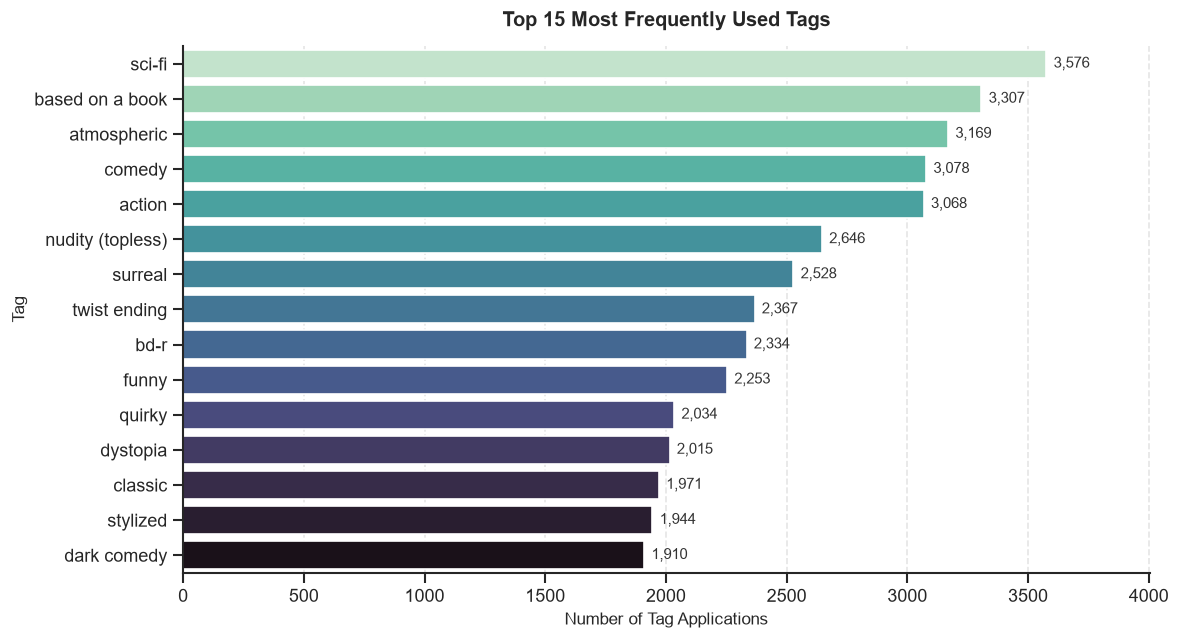

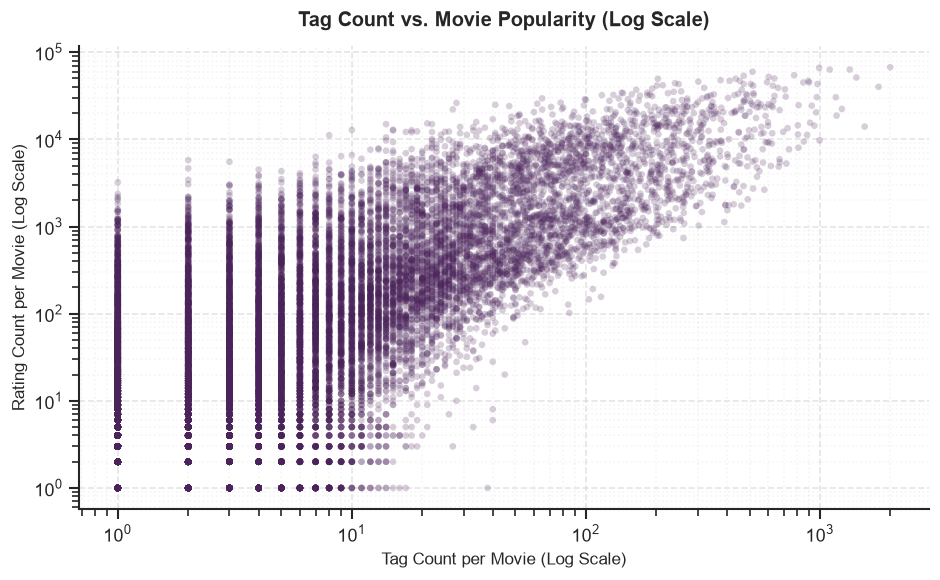

--- Tag Statistics Summary ---
Total tag applications: 465,564
Unique tags count: 35,170
Average tags per tagged movie: 23.82
Max tags assigned to a single movie: 1,994


In [12]:
# ==========================================
# CELL 3: Tags Usage Analysis (Level 2.2)
# ==========================================

# 1. Clean tags (convert to lowercase to unify duplicates)
tags_clean = tags.dropna(subset=['tag']).copy()
tags_clean['tag_lower'] = tags_clean['tag'].astype(str).str.lower().str.strip()

# Top 15 most frequent tags
top_15_tags = tags_clean['tag_lower'].value_counts().head(15)


# --- Plot 1: Top 15 Most Frequent Tags (Horizontal Bar Chart) ---
fig, ax = plt.subplots(figsize=(10, 5.5))
palette = sns.color_palette("mako_r", n_colors=15)

bars = sns.barplot(
    x=top_15_tags.values, 
    y=top_15_tags.index, 
    hue=top_15_tags.index, 
    palette=palette, 
    legend=False, 
    ax=ax
)

# Direkte Beschriftung der Exakten Zahlenwerte neben jedem Balken
for p in bars.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width):,}',
        (width + 30, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        fontsize=9, color='#333333', fontweight='medium'
    )

ax.set_title('Top 15 Most Frequently Used Tags', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Number of Tag Applications', fontsize=10)
ax.set_ylabel('Tag', fontsize=10)
ax.set_xlim(0, top_15_tags.max() * 1.12) # Platz für Zahlenbeschriftungen schaffen

ax.grid(True, axis='x', linestyle='--', alpha=0.5)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


# --- Plot 2: Tag Count vs. Movie Popularity (Scatter Plot) ---
tags_per_movie = tags_clean.groupby('movieId').size().rename('tag_count')
ratings_per_movie = ratings.groupby('movieId').size().rename('rating_count')

df_tag_pop = pd.concat([tags_per_movie, ratings_per_movie], axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))

# Feinere Punkte und höhere Transparenz für bessere Lesbarkeit dichter Cluster
ax.scatter(
    df_tag_pop['tag_count'], 
    df_tag_pop['rating_count'], 
    alpha=0.22, 
    s=16, 
    color='#4a235a', 
    edgecolors='none'
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title('Tag Count vs. Movie Popularity (Log Scale)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Tag Count per Movie (Log Scale)', fontsize=10)
ax.set_ylabel('Rating Count per Movie (Log Scale)', fontsize=10)

ax.grid(True, which="major", linestyle='--', alpha=0.5)
ax.grid(True, which="minor", linestyle=':', alpha=0.2)
sns.despine()
plt.tight_layout()
plt.show()


# --- Print Summary Statistics ---
print("--- Tag Statistics Summary ---")
print(f"Total tag applications: {len(tags):,}")
print(f"Unique tags count: {tags_clean['tag_lower'].nunique():,}")
print(f"Average tags per tagged movie: {tags_per_movie.mean():.2f}")
print(f"Max tags assigned to a single movie: {tags_per_movie.max():,}")

--- Genre Metrics Summary ---
             mean_rating  total_ratings  avg_variance  movie_count
genre_list                                                        
Film-Noir          3.444         216689         0.654          322
Documentary        3.437         244619         0.959         2391
War                3.321        1048618         0.826         1173
IMAX               3.295         492366         0.945          195
Drama              3.262        8857853         0.883        13062
Romance            3.206        3802002         0.900         4029
Musical            3.182         870915         0.991         1016
Animation          3.177        1140476         1.145         1015
Crime              3.167        3298335         0.845         2889
Mystery            3.135        1557282         0.874         1489
Fantasy            3.093        2111403         1.065         1398
Western            3.075         423714         0.896          656
Comedy             3.075        

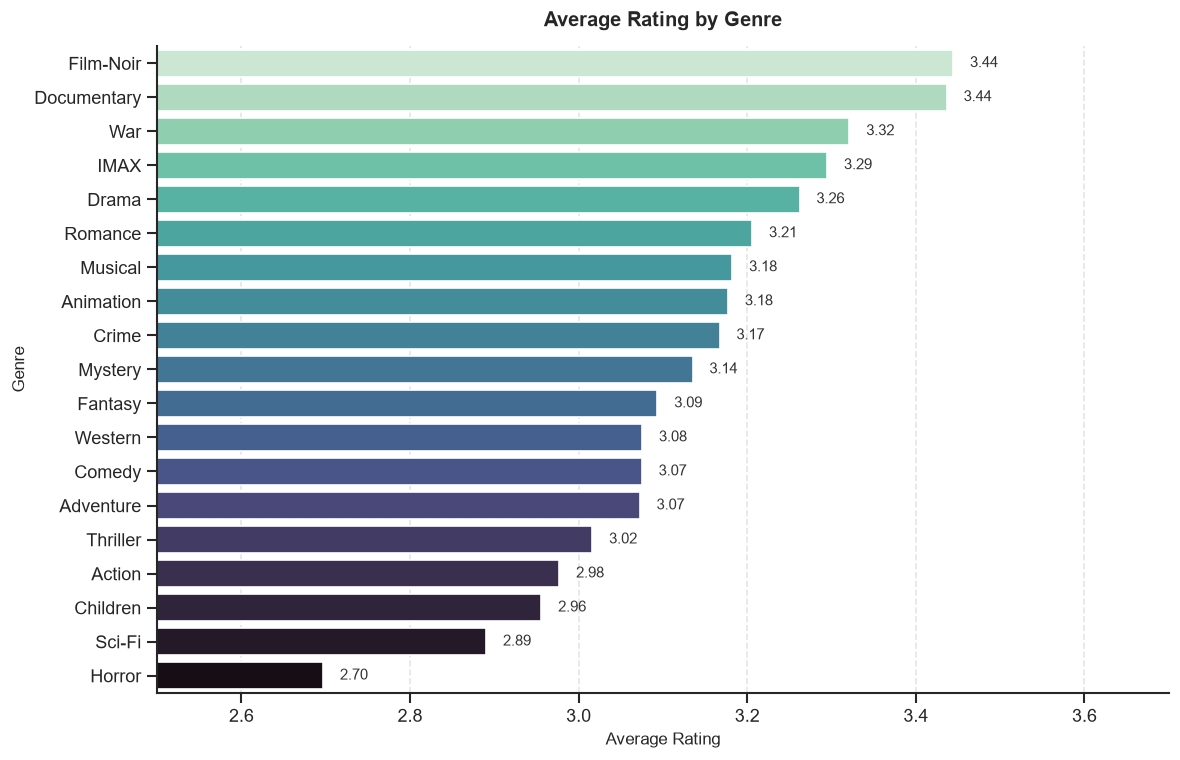


--- Single-Genre vs. Multi-Genre Comparison ---
Single-Genre Movies (Mean): 3.162 (Count: 10575)
Multi-Genre Movies  (Mean): 3.114 (Count: 16169)


C:\Users\wasiq\AppData\Local\Temp\ipykernel_23512\438898953.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Single-Genre', 'Multi-Genre'], fontsize=10)


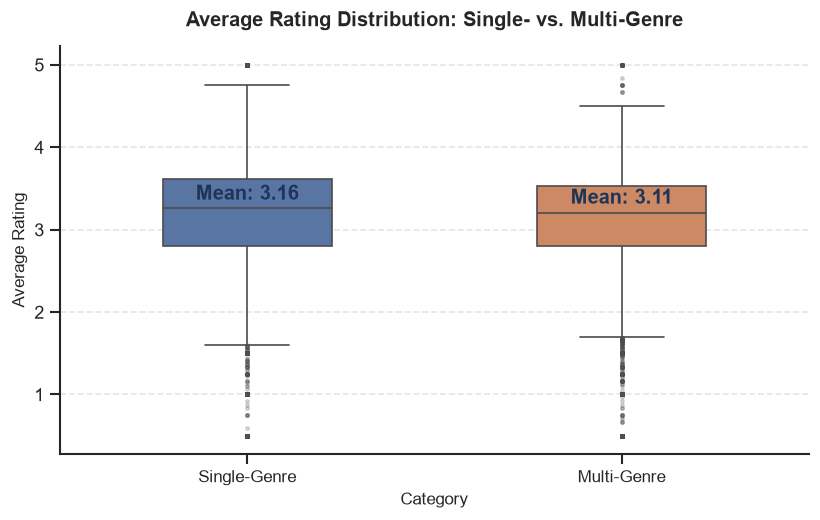


--- Challenge Question 5: Action & Comedy Combination ---
Mean Rating 'Action-only':  2.77
Mean Rating 'Comedy-only':  3.02
Mean Rating 'Action+Comedy': 3.07


In [13]:
# ==========================================
# CELL 4: Genre & Rating Interactions (Level 2.3 & Challenge Question 5)
# ==========================================

# 1. Compute movie-level rating statistics
movie_stats = ratings.groupby('movieId')['rating'].agg(
    avg_rating='mean',
    rating_count='count',
    rating_var='var'
).reset_index()

movies_merged = pd.merge(movies, movie_stats, on='movieId').dropna(subset=['avg_rating'])

# Explode genres into individual rows
movies_exploded = movies_merged.copy()
movies_exploded['genre_list'] = movies_exploded['genres'].str.split('|')
movies_exploded = movies_exploded.explode('genre_list')
movies_exploded = movies_exploded[movies_exploded['genre_list'] != '(no genres listed)']

# Metrics per genre
genre_metrics = movies_exploded.groupby('genre_list').agg(
    mean_rating=('avg_rating', 'mean'),
    total_ratings=('rating_count', 'sum'),
    avg_variance=('rating_var', 'mean'),
    movie_count=('movieId', 'count')
).sort_values(by='mean_rating', ascending=False)

print("--- Genre Metrics Summary ---")
print(genre_metrics.round(3))


# --- Plot 1: Average Rating by Genre (Horizontal Bar Chart) ---
fig, ax = plt.subplots(figsize=(10, 6.5))
palette = sns.color_palette("mako_r", n_colors=len(genre_metrics))

bars = sns.barplot(
    x=genre_metrics['mean_rating'], 
    y=genre_metrics.index, 
    hue=genre_metrics.index, 
    palette=palette, 
    legend=False, 
    ax=ax
)

# Exakte Werte direkt neben jedem Balken anzeigen
for p in bars.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.2f}',
        (width + 0.02, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        fontsize=9, color='#333333', fontweight='medium'
    )

ax.set_title('Average Rating by Genre', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Average Rating', fontsize=10)
ax.set_ylabel('Genre', fontsize=10)

# Fokusbereich der X-Achse eng eingrenzen für optimale Lesbarkeit
ax.set_xlim(2.5, 3.7)

ax.grid(True, axis='x', linestyle='--', alpha=0.5)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


# --- Plot 2: Single- vs. Multi-Genre Comparison (Boxplot) ---
movies_merged['is_multi_genre'] = movies_merged['genres'].str.contains(r'\|')

single_vs_multi = movies_merged.groupby('is_multi_genre')['avg_rating'].agg(['mean', 'count', 'std'])
print("\n--- Single-Genre vs. Multi-Genre Comparison ---")
print(f"Single-Genre Movies (Mean): {single_vs_multi.loc[False, 'mean']:.3f} (Count: {single_vs_multi.loc[False, 'count']})")
print(f"Multi-Genre Movies  (Mean): {single_vs_multi.loc[True, 'mean']:.3f} (Count: {single_vs_multi.loc[True, 'count']})")

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.boxplot(
    x='is_multi_genre', 
    y='avg_rating', 
    hue='is_multi_genre', 
    data=movies_merged, 
    palette=['#4C72B0', '#DD8452'], 
    legend=False, 
    width=0.45,
    fliersize=2.0, # Kleinere Outlier-Punkte
    flierprops={'alpha': 0.2, 'markerfacecolor': '#555555'}, # Transparenter, um Clutter zu vermeiden
    ax=ax
)

ax.set_xticklabels(['Single-Genre', 'Multi-Genre'], fontsize=10)
ax.set_title('Average Rating Distribution: Single- vs. Multi-Genre', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Category', fontsize=10)
ax.set_ylabel('Average Rating', fontsize=10)

# Exakte Mittelwerte als Text auf den Boxplots platzieren
mean_single = single_vs_multi.loc[False, 'mean']
mean_multi = single_vs_multi.loc[True, 'mean']

ax.text(0, mean_single + 0.15, f'Mean: {mean_single:.2f}', ha='center', va='bottom', fontweight='bold', color='#1d3557')
ax.text(1, mean_multi + 0.15, f'Mean: {mean_multi:.2f}', ha='center', va='bottom', fontweight='bold', color='#1d3557')

ax.grid(True, axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()


# --- Challenge Question 5: Action & Comedy Combination ---
pop_movies = movies_merged[movies_merged['rating_count'] >= 100]

action_only = pop_movies[pop_movies['genres'] == 'Action']['avg_rating'].mean()
comedy_only = pop_movies[pop_movies['genres'] == 'Comedy']['avg_rating'].mean()
action_comedy = pop_movies[
    pop_movies['genres'].str.contains('Action') & pop_movies['genres'].str.contains('Comedy')
]['avg_rating'].mean()

print("\n--- Challenge Question 5: Action & Comedy Combination ---")
print(f"Mean Rating 'Action-only':  {action_only:.2f}")
print(f"Mean Rating 'Comedy-only':  {comedy_only:.2f}")
print(f"Mean Rating 'Action+Comedy': {action_comedy:.2f}")

C:\Users\wasiq\AppData\Local\Temp\ipykernel_23512\1111425625.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax6.set_xticklabels(['Single-Genre', 'Multi-Genre'], fontsize=9)


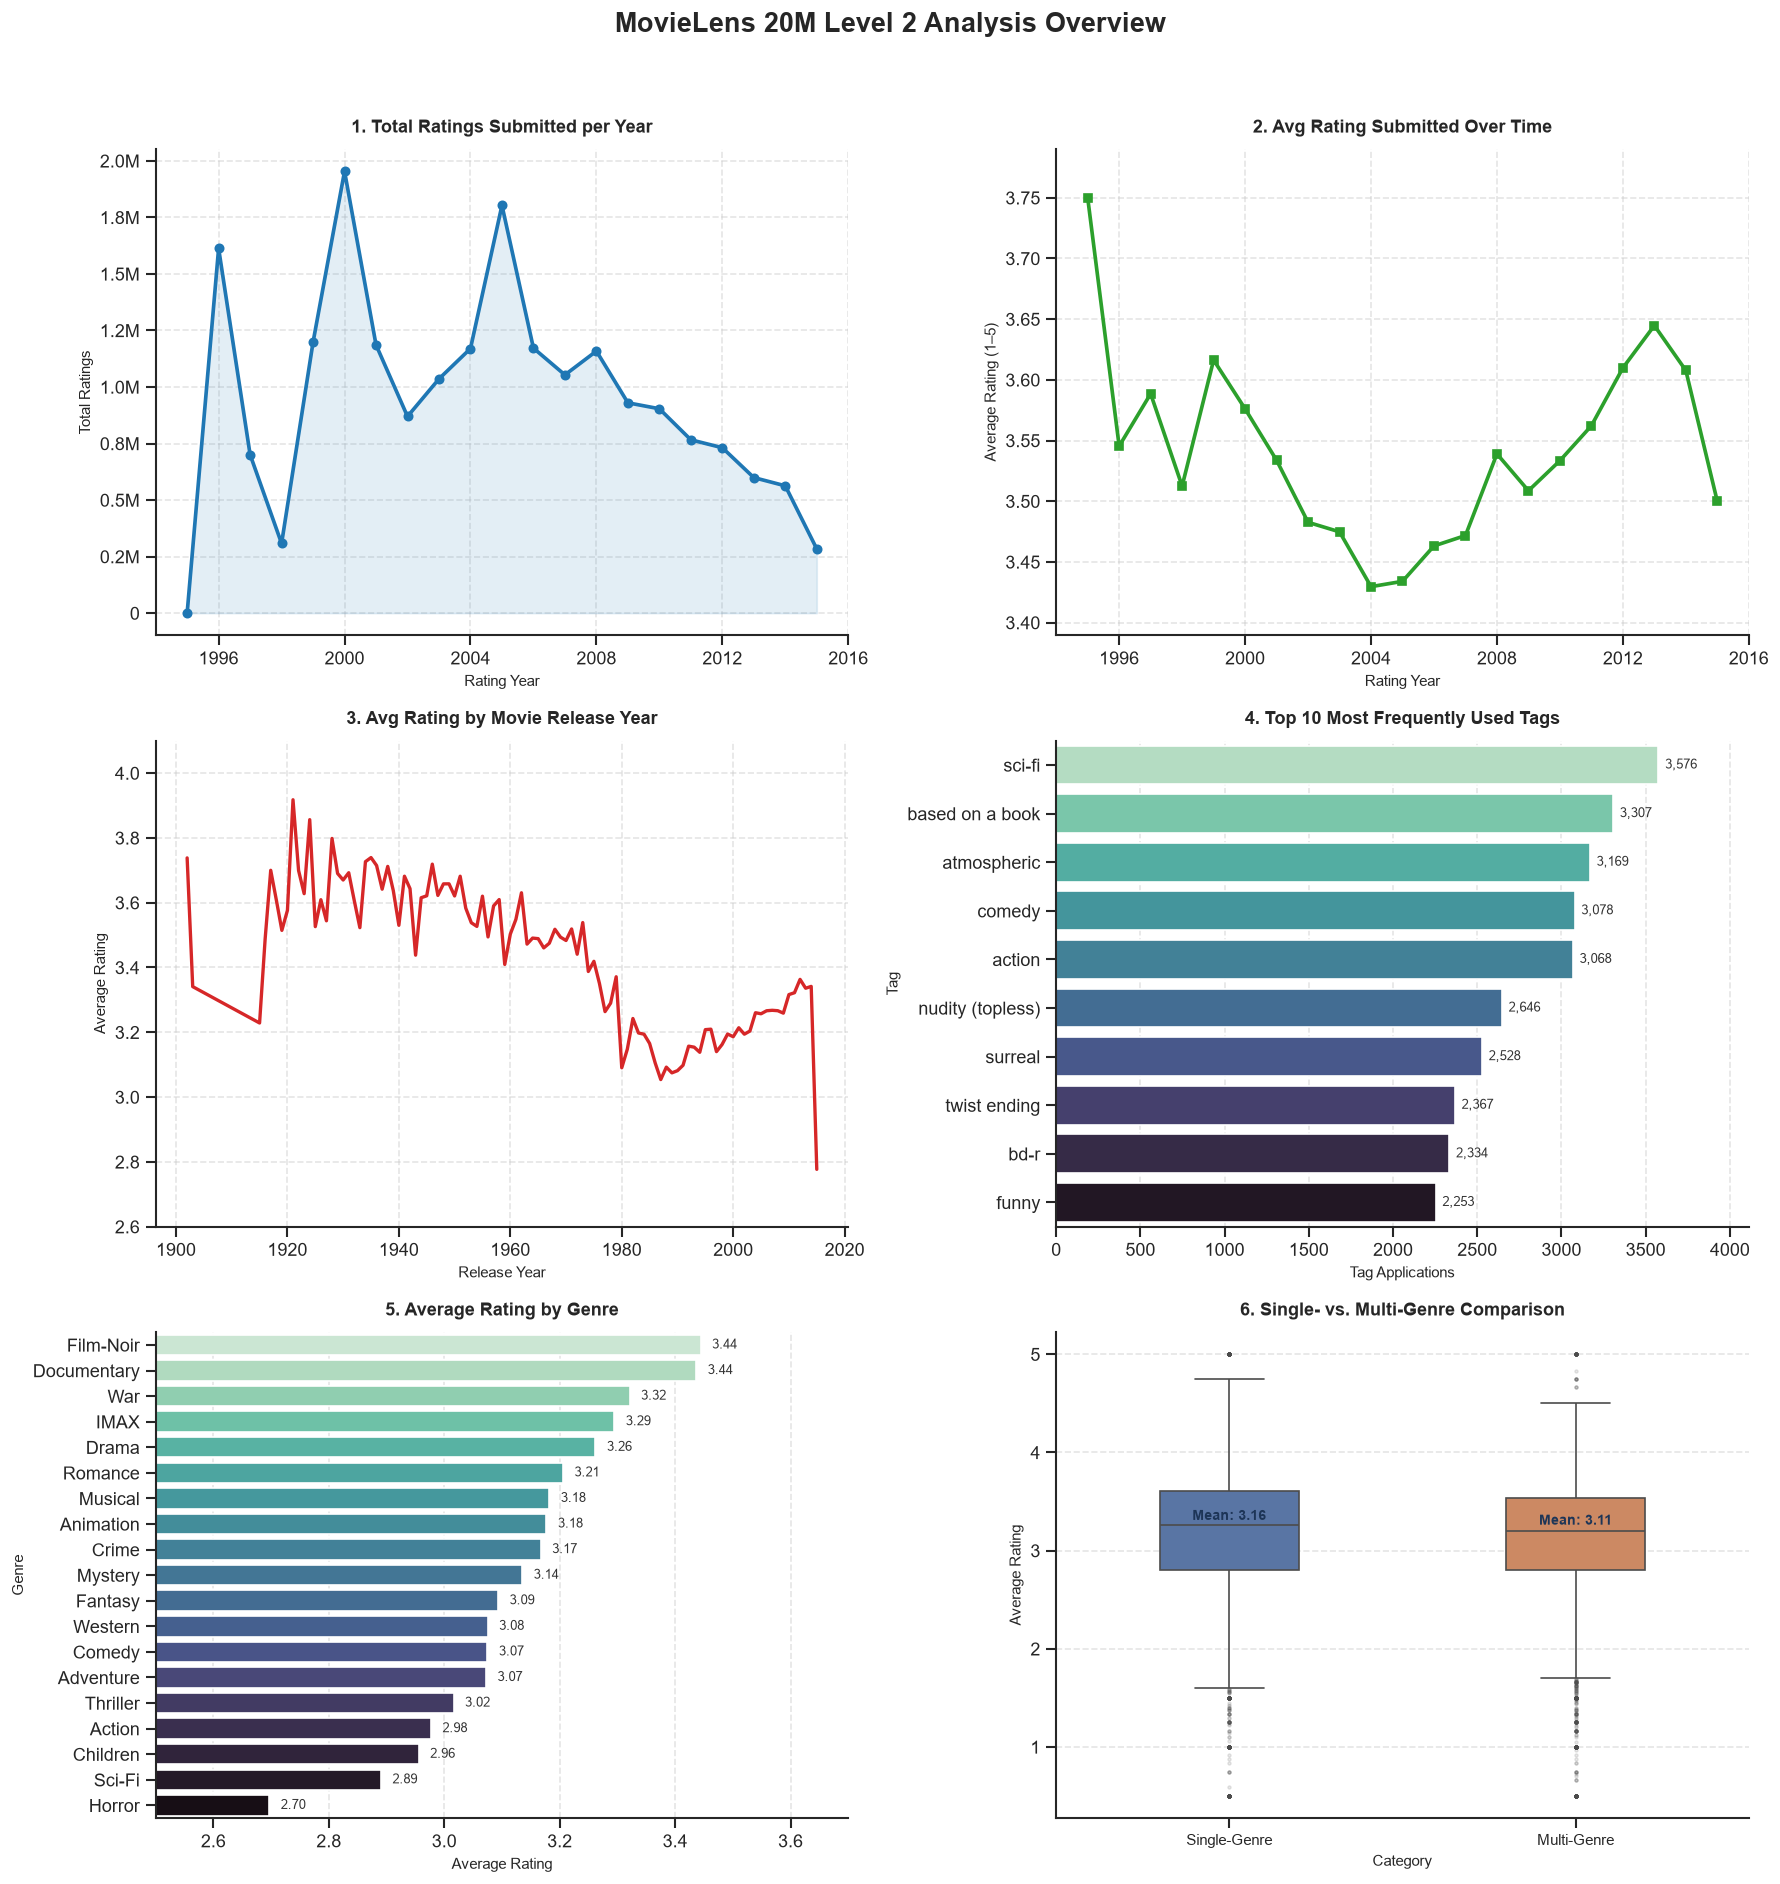

In [15]:
# ==========================================
# ALL-IN-ONE DASHBOARD (Refined & Clean)
# ==========================================
import matplotlib.ticker as ticker

fig = plt.figure(figsize=(15, 16))
plt.suptitle('MovieLens 20M Level 2 Analysis Overview', fontsize=16, fontweight='bold', y=0.98)

# --- 1. Ratings per Year ---
ax1 = plt.subplot(3, 2, 1)
ratings_per_year = ratings.groupby('rating_year').size()
ax1.plot(ratings_per_year.index, ratings_per_year.values, marker='o', color='#1f77b4', linewidth=2.2, markersize=5)
ax1.fill_between(ratings_per_year.index, ratings_per_year.values, color='#1f77b4', alpha=0.12)
ax1.set_title('1. Total Ratings Submitted per Year', fontweight='bold', fontsize=11, pad=10)
ax1.set_xlabel('Rating Year', fontsize=9)
ax1.set_ylabel('Total Ratings', fontsize=9)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(4))
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x*1e-6:.1f}M' if x > 0 else '0'))
ax1.grid(True, linestyle='--', alpha=0.5)

# --- 2. Avg Rating Submitted Over Time ---
ax2 = plt.subplot(3, 2, 2)
avg_rating_per_year = ratings.groupby('rating_year')['rating'].mean()
ax2.plot(avg_rating_per_year.index, avg_rating_per_year.values, marker='s', color='#2ca02c', linewidth=2.2, markersize=5)
ax2.set_title('2. Avg Rating Submitted Over Time', fontweight='bold', fontsize=11, pad=10)
ax2.set_xlabel('Rating Year', fontsize=9)
ax2.set_ylabel('Average Rating (1–5)', fontsize=9)
ax2.set_ylim(avg_rating_per_year.min() - 0.04, avg_rating_per_year.max() + 0.04)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(4))
ax2.grid(True, linestyle='--', alpha=0.5)

# --- 3. Avg Rating by Release Year (FIXED SCALE) ---
ax3 = plt.subplot(3, 2, 3)
movie_avg_ratings = ratings.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index()
movies_with_ratings = pd.merge(movies, movie_avg_ratings, on='movieId')
filtered_movies = movies_with_ratings[(movies_with_ratings['release_year'] >= 1900) & (movies_with_ratings['count'] >= 50)]
avg_by_release = filtered_movies.groupby('release_year')['mean'].mean()

ax3.plot(avg_by_release.index, avg_by_release.values, color='#d62728', linewidth=2)
ax3.set_title('3. Avg Rating by Movie Release Year', fontweight='bold', fontsize=11, pad=10)
ax3.set_xlabel('Release Year', fontsize=9)
ax3.set_ylabel('Average Rating', fontsize=9)
# Fokus auf den relevanten Rating-Bereich setzen
ax3.set_ylim(2.6, 4.1)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax3.grid(True, linestyle='--', alpha=0.5)

# --- 4. Top 10 Most Used Tags ---
ax4 = plt.subplot(3, 2, 4)
tags_clean = tags.dropna(subset=['tag']).copy()
tags_clean['tag_lower'] = tags_clean['tag'].astype(str).str.lower().str.strip()
top_10_tags = tags_clean['tag_lower'].value_counts().head(10)

bars4 = sns.barplot(x=top_10_tags.values, y=top_10_tags.index, hue=top_10_tags.index, palette="mako_r", legend=False, ax=ax4)
for p in bars4.patches:
    w = p.get_width()
    ax4.annotate(f'{int(w):,}', (w + 40, p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=8, color='#333')

ax4.set_title('4. Top 10 Most Frequently Used Tags', fontweight='bold', fontsize=11, pad=10)
ax4.set_xlabel('Tag Applications', fontsize=9)
ax4.set_ylabel('Tag', fontsize=9)
ax4.set_xlim(0, top_10_tags.max() * 1.15)
ax4.grid(True, axis='x', linestyle='--', alpha=0.5)

# --- 5. Avg Rating by Genre ---
ax5 = plt.subplot(3, 2, 5)
movies_exploded = movies_with_ratings.copy()
movies_exploded['genre_list'] = movies_exploded['genres'].str.split('|')
movies_exploded = movies_exploded.explode('genre_list')
movies_exploded = movies_exploded[movies_exploded['genre_list'] != '(no genres listed)']
genre_means = movies_exploded.groupby('genre_list')['mean'].mean().sort_values(ascending=False)

bars5 = sns.barplot(x=genre_means.values, y=genre_means.index, hue=genre_means.index, palette="mako_r", legend=False, ax=ax5)
for p in bars5.patches:
    w = p.get_width()
    ax5.annotate(f'{w:.2f}', (w + 0.02, p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=8, color='#333')

ax5.set_title('5. Average Rating by Genre', fontweight='bold', fontsize=11, pad=10)
ax5.set_xlabel('Average Rating', fontsize=9)
ax5.set_ylabel('Genre', fontsize=9)
ax5.set_xlim(2.5, 3.7)
ax5.grid(True, axis='x', linestyle='--', alpha=0.5)

# --- 6. Single- vs. Multi-Genre ---
ax6 = plt.subplot(3, 2, 6)
movies_with_ratings['is_multi_genre'] = movies_with_ratings['genres'].str.contains(r'\|')
single_vs_multi = movies_with_ratings.groupby('is_multi_genre')['mean'].mean()

sns.boxplot(
    x='is_multi_genre', y='mean', hue='is_multi_genre', 
    data=movies_with_ratings, palette=['#4C72B0', '#DD8452'], 
    legend=False, width=0.4, fliersize=1.5, 
    flierprops={'alpha': 0.2}, ax=ax6
)

ax6.set_xticklabels(['Single-Genre', 'Multi-Genre'], fontsize=9)
ax6.set_title('6. Single- vs. Multi-Genre Comparison', fontweight='bold', fontsize=11, pad=10)
ax6.set_xlabel('Category', fontsize=9)
ax6.set_ylabel('Average Rating', fontsize=9)

# Mittelwert als Text über den Boxen anzeigen
ax6.text(0, single_vs_multi.loc[False] + 0.15, f'Mean: {single_vs_multi.loc[False]:.2f}', ha='center', fontweight='bold', color='#1d3557', fontsize=8.5)
ax6.text(1, single_vs_multi.loc[True] + 0.15, f'Mean: {single_vs_multi.loc[True]:.2f}', ha='center', fontweight='bold', color='#1d3557', fontsize=8.5)
ax6.grid(True, axis='y', linestyle='--', alpha=0.5)

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()